Analistes de Finances i Risc Crediticio: En quina mesura els clients amb saldos més baixos estan 
en més risc d'incompliment de crèdit, i com hem d'ajustar les nostres polítiques de crèdit per 
mitigar aquest risc?

In [13]:
import mysql.connector
from mysql.connector import Error

import pandas as pd

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [14]:
df_bank = pd.read_csv(r"C:\Users\damia\ProjecteData\Equip_23\Data\23 February\Bank_Marketing_Cleaned-23_February.csv")

df_bank.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,no,2343,yes,no,unknown,5,5,1042,1,-1,0,unknown,yes
1,2,56,admin.,married,secondary,no,45,no,no,unknown,5,5,1467,1,-1,0,unknown,yes
2,3,41,technician,married,secondary,no,1270,yes,no,unknown,5,5,1389,1,-1,0,unknown,yes
3,4,55,services,married,secondary,no,2476,yes,no,unknown,5,5,579,1,-1,0,unknown,yes
4,5,54,admin.,married,tertiary,no,184,no,no,unknown,5,5,673,2,-1,0,unknown,yes


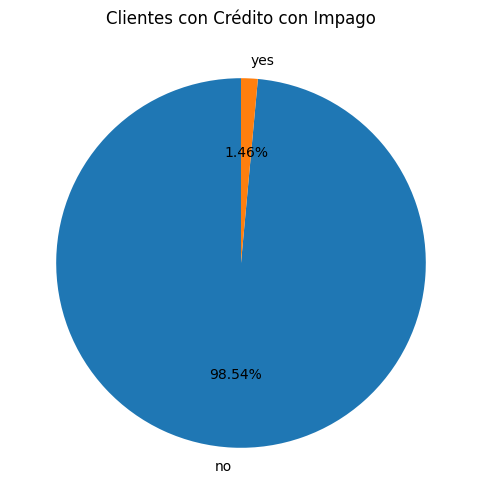

In [15]:
# ¿Cuál es el nivel general de riesgo?
# El nivel general de incumplimiento en la cartera es bajo (1.5%), lo que indica una situación estable a nivel agregado. 
# Sin embargo, este dato promedio puede ocultar concentraciones de riesgo en ciertos segmentos, por lo que es necesario analizar el comportamiento por nivel de saldo.

# preparamos los datos
grafico = df_bank['default'].value_counts()

# dibujamos el gráfico
grafico.plot.pie(autopct='%1.2f%%', figsize=(6,6), startangle=90)

plt.title('Clientes con Crédito con Impago')
plt.ylabel('')
plt.show()

# DEFAULT GENERAL PARA CSV

default_general = (
    df_bank["default"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

default_general.columns = ["default", "percentage"]

# Exportar CSV
default_general.to_csv("default_general.csv", index=False)



balance_type
negativo    11.455108
positivo     0.810324
Name: default, dtype: float64
El riesgo es 14.1 veces mayor en balances negativos


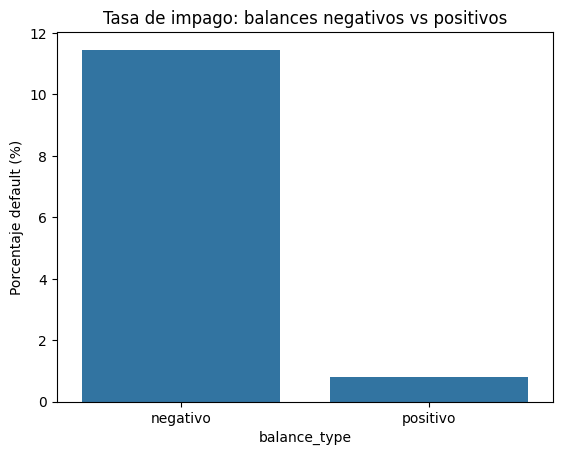

In [ ]:
# ¿Cuánto aumenta el riesgo si el saldo es negativo?
# Aunque el nivel general de default es bajo, el riesgo no está distribuido de manera uniforme. 
# Los clientes con balance negativo presentan una tasa de impago del 11.45%, frente a solo 0.81% en clientes con balance positivo. 
# Esto implica que el riesgo es aproximadamente 14 veces mayor cuando el cliente tiene saldo negativo. Por tanto, el balance es un fuerte predictor de incumplimiento. 
# El problema no es general, está concentrado.

# Crear grupo balance negativo vs positivo
df_bank["balance_type"] = df_bank["balance"].apply(
    lambda x: "negativo" if x < 0 else "positivo"
)

# tasa default por grupo
default_rate_balance = df_bank.groupby("balance_type")["default"].apply(
    lambda x: (x == "yes").mean() * 100
)

print(default_rate_balance)

# Cuántas veces aumenta el riesgo

negativo = default_rate_balance["negativo"]
positivo = default_rate_balance["positivo"]

risk_ratio = negativo / positivo

print(f"El riesgo es {risk_ratio:.1f} veces mayor en balances negativos")

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x=default_rate_balance.index,
    y=default_rate_balance.values
)

plt.title("Tasa de impago: balances negativos vs positivos")
plt.ylabel("Porcentaje default (%)")

plt.show()

# Convertir a formato tabla y exportar CSV

default_rate_balance = (
    df_bank.groupby("balance_type")["default"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index()
)

default_rate_balance.columns = ["balance_type", "default_percentage"]

default_rate_balance.to_csv("negativos_vs_positivos.csv", index=False)

C:\Users\damia\AppData\Local\Temp\ipykernel_15576\2343851373.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("neg_balance_group")["default"]


default                   no        yes
neg_balance_group                      
-1500 a -1000      72.727273  27.272727
-1000 a -500       80.645161  19.354839
-500 a -250        88.442211  11.557789
-250 a -100        92.666667   7.333333
-100 a 0           90.760870   9.239130


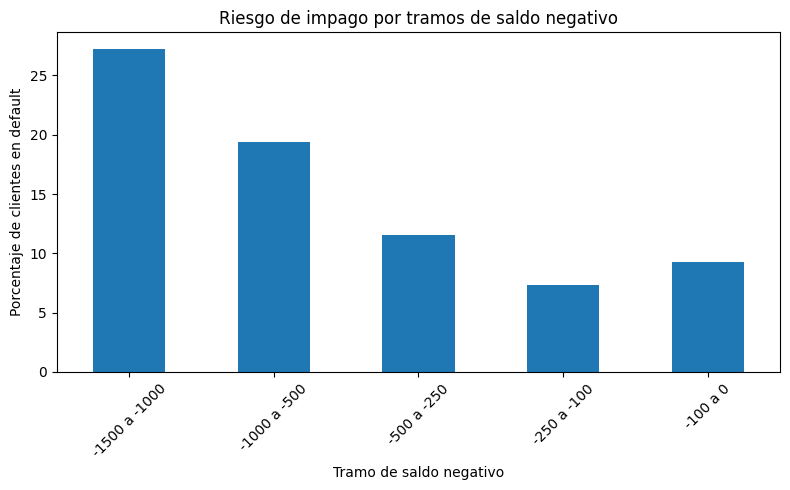

C:\Users\damia\AppData\Local\Temp\ipykernel_15576\2343851373.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("neg_balance_group")["default"]


,balance_tramo,default_percentage
0,-1500 a -1000,27.272727
1,-1000 a -500,19.354839
2,-500 a -250,11.557789
3,-250 a -100,7.333333
4,-100 a 0,9.239130


In [17]:
#¿A partir de qué nivel de saldo negativo el riesgo de incumplimiento comienza a ser significativo o crítico?
# El riesgo de incumplimiento no aumenta de forma lineal, sino que se incrementa progresivamente conforme el saldo se vuelve más negativo. 
# Observamos que a partir de aproximadamente -250 el riesgo comienza a elevarse, y por debajo de -500 el incremento es significativamente mayor. 
# En niveles inferiores a -1000, la tasa de impago alcanza niveles críticos.Esto indica la existencia de umbrales de riesgo claramente identificables, 
# lo que permite diseñar políticas preventivas antes de que el cliente entre en una zona crítica.

import pandas as pd
import matplotlib.pyplot as plt

#  Filtrar solo balances negativos dentro del rango deseado
df_negativos = df_bank[
    (df_bank["balance"] < 0) &
    (df_bank["balance"] >= -1500)
].copy()

# Definir tramos
bins = [-1500, -1000, -500, -250, -100, 0]
labels = [
    "-1500 a -1000",
    "-1000 a -500",
    "-500 a -250",
    "-250 a -100",
    "-100 a 0"
]

# Asignar tramo
df_negativos["neg_balance_group"] = pd.cut(
    df_negativos["balance"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

#  Calcular riesgo
riesgo_neg = (
    df_negativos
    .groupby("neg_balance_group")["default"]
    .value_counts(normalize=True)
    .unstack() * 100
)

print(riesgo_neg)

# Graficar solo porcentaje de default (yes)
riesgo_neg["yes"].plot(kind="bar", figsize=(8,5))

plt.title("Riesgo de impago por tramos de saldo negativo")
plt.xlabel("Tramo de saldo negativo")
plt.ylabel("Porcentaje de clientes en default")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Convertir riesgo a formato tabla limpio

riesgo_tramos_export = (
    df_negativos
    .groupby("neg_balance_group")["default"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index()
)

riesgo_tramos_export.columns = ["balance_tramo", "default_percentage"]

# Exportar CSV
riesgo_tramos_export.to_csv("riesgo_tramos_negativos.csv", index=False)

riesgo_tramos_export

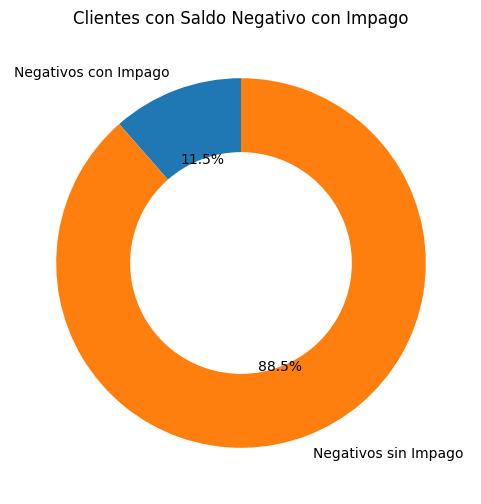

In [18]:
# ¿A quién está afectando realmente?
# Dentro del segmento de clientes con saldo negativo, aproximadamente el 11.5% ya presenta incumplimiento. Esto confirma que el riesgo se concentra en este grupo. 
# Sin embargo, la mayoría aún no ha caído en default, lo que sugiere una oportunidad clara de intervención preventiva antes de que el deterioro sea mayor.

import matplotlib.pyplot as plt

# Filtrar clientes con balance negativo
df_negativos = df_bank[df_bank["balance"] < 0]

# Contar default dentro de negativos
neg_default_yes = len(df_negativos[df_negativos["default"] == "yes"])
neg_default_no = len(df_negativos[df_negativos["default"] == "no"])

labels = ["Negativos con Impago", "Negativos sin Impago"]
sizes = [neg_default_yes, neg_default_no]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Clientes con Saldo Negativo con Impago")

plt.show()

# Crear tabla para exportar

neg_default_export = (
    df_negativos["default"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

neg_default_export.columns = ["default_status", "percentage"]

# Exportar CSV
neg_default_export.to_csv("negativos_en_default.csv", index=False)


## Resultados del análisis

Los resultados muestran que los clientes con saldos más bajos presentan un mayor riesgo de impago. 
Para reducir este riesgo sin excluir a ningun cliente, la entidad puede aplicar medidas como:

**1. Análisis del tipo de riesgo** Se realiza un análisis más exaustivo del historial de pagos y el tipo de cliente que es para adaptar las condiciones del crédito a su perfil financiero

**2. Programas de educación financiera** Ofrecer asesoramiento o formación a clientes con saldos bajos para ayudarles a mejorar su gestión económica y reducir el riesgo de impago

**3. Ajustar la cantidad de crédito inicial** Se ofrecen créditos iniciales más bajos y se puede aumentar esta cantidad en función del comportamiento de pagos. Esto ayudará a controlar el riesgo sin excluir a nadie.

**3. Acompañamiento** Los clientes con saldos bajos recibirán más atencion para ajustar las condiciones en tiempo real. 


# Anotaciones

*Se pensaron en unas políticas muy inclusivas y suaves para no marginar a ningun tipo de cliente*

Estaba pensando en analizar que tipo de cliente es el que tiene las deudas pero creo que no lo piden. 


# Clientes < –500:

Revisión inmediata de condiciones.

Límites de crédito más conservadores.

Seguimiento mensual o quincenal.

# Clientes entre –500 y –250:

Alertas preventivas.

Revisión de ingresos y comportamiento histórico.

# Clientes entre –250 y –100:

Monitorización ligera.

Posible ajuste de límites si hay tendencia a empeorar.

# Clientes entre –100 y 0:

Educación financiera y recordatorios de pago.

Productos que eviten entrar en descubierto (cuentas con protección, microcréditos controlados).

Se observa que el riesgo de incumplimiento comienza a incrementarse de forma significativa a partir de balances inferiores a -250, alcanzando niveles críticos por debajo de -500, donde prácticamente se duplica la tasa de impago.

Recomendaciones:

Alertas tempranas cuando el balance sea negativo.

Revisión manual para balances inferiores a -500.

Reducción del límite crediticio en clientes con balances negativos.

Incentivos para mantener balances positivos.